# Particle Filtering (Sequential Monte Carlo)

This notebook implements the **Bootstrap Particle Filter** (also known as Sampling Importance Resampling, SIR) for sequential state estimation in a hidden Markov model.

### What is a Particle Filter?
A particle filter approximates the posterior distribution $p(x_t | y_{1:t})$ over the hidden state using a set of weighted random samples called **particles**:

$$p(x_t | y_{1:t}) \approx \sum_{i=1}^N w_t^{(i)} \, \delta(x_t - x_t^{(i)})$$

As new observations arrive, the filter recursively:
1. **Propagates** particles through the state transition
2. **Weights** them by the observation likelihood
3. **Resamples** to eliminate particles with negligible weight

We benchmark against the **Kalman Filter**, which is optimal for the linear-Gaussian case.


In [7]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11


## 1. State-Space Model and Synthetic Data

We use a simple linear-Gaussian state-space model so that the Kalman filter provides a ground-truth benchmark.

**State equation:** $x_t = x_{t-1} + v_t, \quad v_t \sim \mathcal{N}(0, Q)$

**Observation equation:** $y_t = x_t + w_t, \quad w_t \sim \mathcal{N}(0, R)$

This is a random walk observed with additive noise. The Kalman filter is optimal here; the particle filter should closely match it.


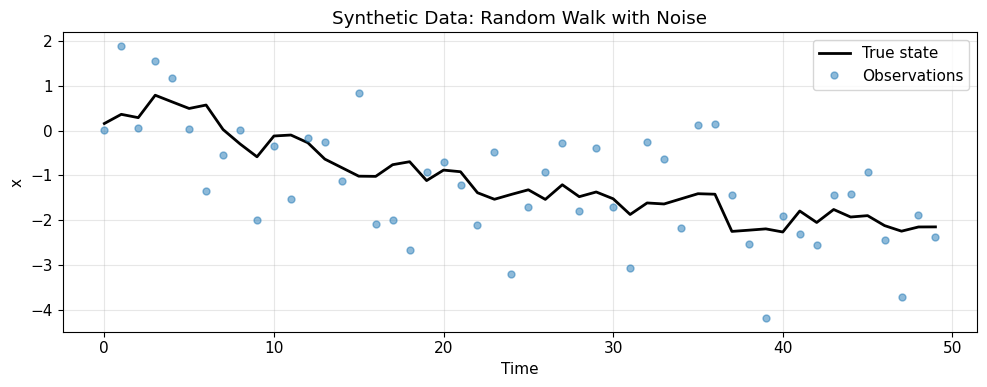

In [8]:
# Model parameters
T = 50          # time steps
Q = 0.1         # process noise variance
R = 1.0         # observation noise variance
x0 = 0.0        # initial true state

# Generate synthetic data
x_true = np.zeros(T)
y_obs = np.zeros(T)
x_true[0] = x0 + np.sqrt(Q) * np.random.randn()
y_obs[0] = x_true[0] + np.sqrt(R) * np.random.randn()

for t in range(1, T):
    x_true[t] = x_true[t-1] + np.sqrt(Q) * np.random.randn()
    y_obs[t] = x_true[t] + np.sqrt(R) * np.random.randn()

# Quick look
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(T), x_true, 'k-', lw=2, label='True state')
ax.plot(range(T), y_obs, 'o', alpha=0.5, markersize=5, label='Observations')
ax.set_title('Synthetic Data: Random Walk with Noise')
ax.set_xlabel('Time')
ax.set_ylabel('x')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 2. Bootstrap Particle Filter (SIR)

**Algorithm:**

1. **Initialize:** Draw $x_0^{(i)} \sim p(x_0)$, set $w_0^{(i)} = 1/N$
2. **For** $t = 1, 2, \dots, T$:
   - **Resample:** Draw indices $a^{(i)} \sim \text{Categorical}(w_{t-1})$ and set $\tilde{x}_{t-1}^{(i)} = x_{t-1}^{(a^{(i)})}$
   - **Propagate:** $x_t^{(i)} \sim p(x_t | \tilde{x}_{t-1}^{(i)})$
   - **Weight:** $w_t^{(i)} \propto p(y_t | x_t^{(i)})$, then normalize

**Effective Sample Size (ESS):**
$$\text{ESS}_t = \frac{1}{\sum_{i=1}^N (w_t^{(i)})^2}$$

If $\text{ESS} \ll N$, weights are concentrated on a few particles and the approximation is poor. Resampling restores diversity.

We also implement the **optimal Kalman filter** for comparison.


In [9]:
def bootstrap_pf(y, N, Q, R, x0_mean=0.0, x0_std=1.0):
    """
    Standard bootstrap particle filter with resampling at every step.
    """
    T = len(y)
    particles = np.zeros((T, N))
    weights = np.zeros((T, N))
    ess = np.zeros(T)
    
    # Initialize
    particles[0, :] = x0_mean + x0_std * np.random.randn(N)
    lik = np.exp(-0.5 * ((y[0] - particles[0, :])**2) / R)
    w = lik / np.sum(lik)
    weights[0, :] = w
    ess[0] = 1.0 / np.sum(w**2)
    
    for t in range(1, T):
        # Resample
        indices = np.random.choice(N, size=N, replace=True, p=w)
        particles_prev = particles[t-1, indices]
        
        # Propagate
        particles[t, :] = particles_prev + np.sqrt(Q) * np.random.randn(N)
        
        # Weight
        lik = np.exp(-0.5 * ((y[t] - particles[t, :])**2) / R)
        w = lik / np.sum(lik)
        weights[t, :] = w
        ess[t] = 1.0 / np.sum(w**2)
    
    x_est = np.sum(particles * weights, axis=1)
    return particles, weights, x_est, ess


def pf_no_resample(y, N, Q, R, x0_mean=0.0, x0_std=1.0):
    """
    PF without resampling: demonstrates weight collapse.
    """
    T = len(y)
    particles = np.zeros((T, N))
    weights = np.zeros((T, N))
    
    particles[0, :] = x0_mean + x0_std * np.random.randn(N)
    w = np.exp(-0.5 * ((y[0] - particles[0, :])**2) / R)
    w /= np.sum(w)
    weights[0, :] = w
    
    for t in range(1, T):
        particles[t, :] = particles[t-1, :] + np.sqrt(Q) * np.random.randn(N)
        lik = np.exp(-0.5 * ((y[t] - particles[t, :])**2) / R)
        w = w * lik
        w /= np.sum(w)
        weights[t, :] = w
    
    x_est = np.sum(particles * weights, axis=1)
    return particles, weights, x_est


def kalman_filter(y, Q, R, x0, P0):
    """
    Optimal Kalman filter for the random-walk model.
    """
    T = len(y)
    x_est = np.zeros(T)
    P_est = np.zeros(T)
    x = x0
    P = P0
    for t in range(T):
        # Update
        K = P / (P + R)
        x = x + K * (y[t] - x)
        P = (1.0 - K) * P
        x_est[t] = x
        P_est[t] = P
        # Predict
        P = P + Q
    return x_est, P_est


# Run filters
N = 200
particles, weights, x_pf, ess = bootstrap_pf(y_obs, N, Q, R, x0_mean=0.0, x0_std=1.0)
x_kf, P_kf = kalman_filter(y_obs, Q, R, 0.0, 1.0)


## 3. Results and Diagnostics

We visualize:
- The filtered state estimate against the true state and observations
- Particle clouds at selected time steps (colored by weight)
- Effective Sample Size over time
- Weight entropy as a measure of particle diversity

For this linear-Gaussian model, the particle filter should closely track the Kalman filter.


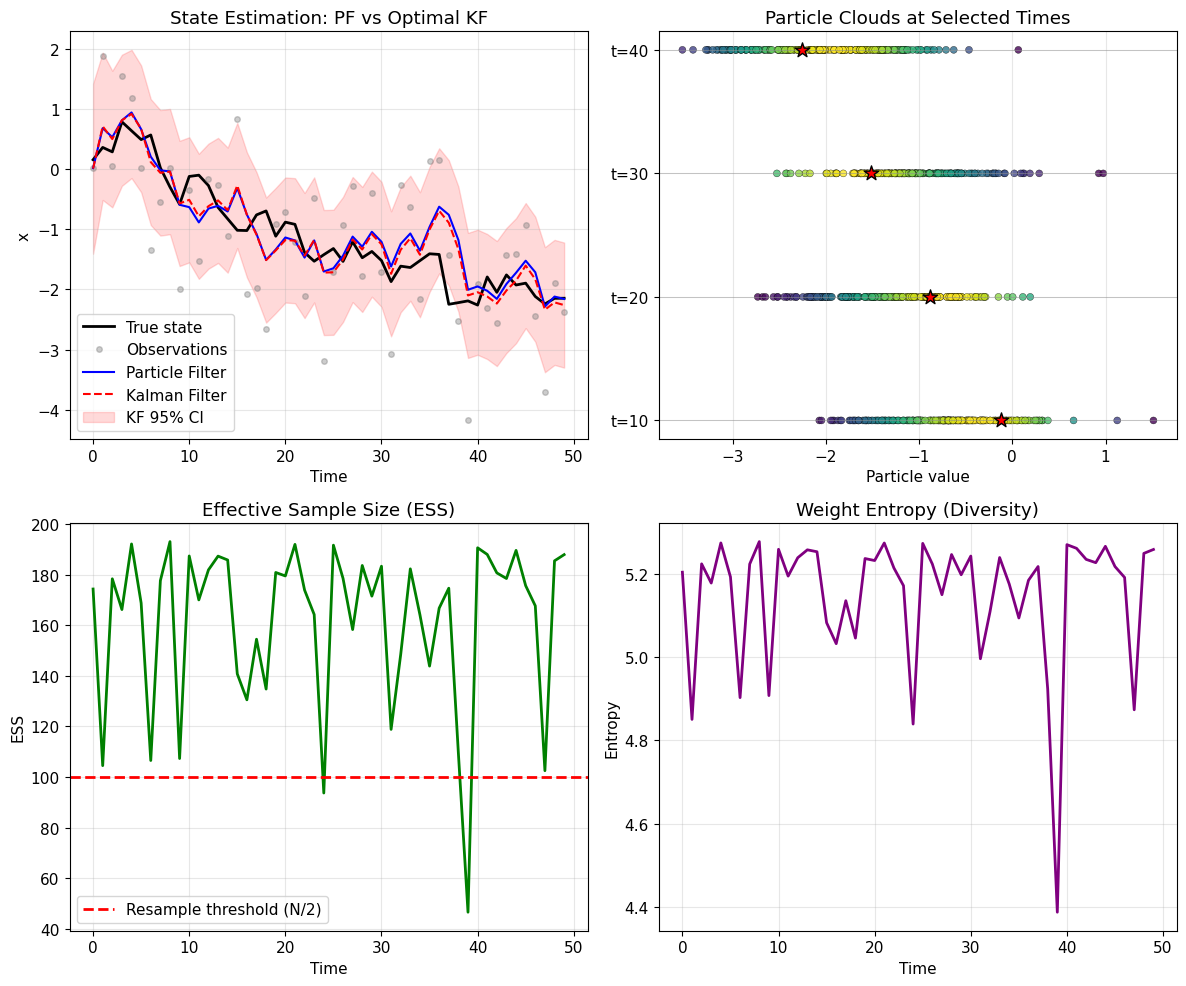

RMSE Particle Filter: 0.4210
RMSE Kalman Filter:   0.3908


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# (0,0) State estimation comparison
axes[0, 0].plot(range(T), x_true, 'k-', lw=2, label='True state')
axes[0, 0].plot(range(T), y_obs, 'o', alpha=0.4, markersize=4, color='gray', label='Observations')
axes[0, 0].plot(range(T), x_pf, 'b-', lw=1.5, label='Particle Filter')
axes[0, 0].plot(range(T), x_kf, 'r--', lw=1.5, label='Kalman Filter')
kf_upper = x_kf + 2.0 * np.sqrt(P_kf)
kf_lower = x_kf - 2.0 * np.sqrt(P_kf)
axes[0, 0].fill_between(range(T), kf_lower, kf_upper, alpha=0.15, color='red', label='KF 95% CI')
axes[0, 0].set_title('State Estimation: PF vs Optimal KF')
axes[0, 0].set_xlabel('Time')
axes[0, 0].set_ylabel('x')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# (0,1) Particle clouds at selected times
selected_t = [10, 20, 30, 40]
for i, t in enumerate(selected_t):
    y_offset = i * 0.15
    sc = axes[0, 1].scatter(particles[t, :], np.zeros(N) + y_offset,
                              c=weights[t, :], cmap='viridis', s=25, alpha=0.8,
                              edgecolors='black', linewidth=0.3)
    axes[0, 1].axhline(y_offset, color='gray', lw=0.5, alpha=0.5)
    axes[0, 1].scatter(x_true[t], y_offset, c='red', s=120, marker='*', zorder=5, edgecolors='black')
axes[0, 1].set_title('Particle Clouds at Selected Times')
axes[0, 1].set_xlabel('Particle value')
axes[0, 1].set_yticks([i * 0.15 for i in range(len(selected_t))])
axes[0, 1].set_yticklabels(['t={}'.format(t) for t in selected_t])
axes[0, 1].grid(True, alpha=0.3)

# (1,0) ESS over time
axes[1, 0].plot(range(T), ess, 'g-', lw=2)
axes[1, 0].axhline(N / 2.0, color='red', linestyle='--', lw=2, label='Resample threshold (N/2)')
axes[1, 0].set_title('Effective Sample Size (ESS)')
axes[1, 0].set_xlabel('Time')
axes[1, 0].set_ylabel('ESS')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# (1,1) Weight entropy over time
entropy = -np.sum(weights * np.log(weights + 1e-12), axis=1)
axes[1, 1].plot(range(T), entropy, color='purple', lw=2)
axes[1, 1].set_title('Weight Entropy (Diversity)')
axes[1, 1].set_xlabel('Time')
axes[1, 1].set_ylabel('Entropy')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

rmse_pf = np.sqrt(np.mean((x_pf - x_true)**2))
rmse_kf = np.sqrt(np.mean((x_kf - x_true)**2))
print("RMSE Particle Filter: {:.4f}".format(rmse_pf))
print("RMSE Kalman Filter:   {:.4f}".format(rmse_kf))


## 4. The Curse of Weight Collapse (No Resampling)

Without resampling, weights accumulate over time. Eventually, one particle dominates and the effective sample size collapses to 1. This is called **degeneracy** or **weight collapse**.

We compare:
- **With resampling:** Healthy particle diversity, stable tracking
- **Without resampling:** Weights concentrate, posterior approximation becomes a single delta function, and the filter loses track

This demonstrates why resampling is the critical innovation that makes sequential Monte Carlo practical.


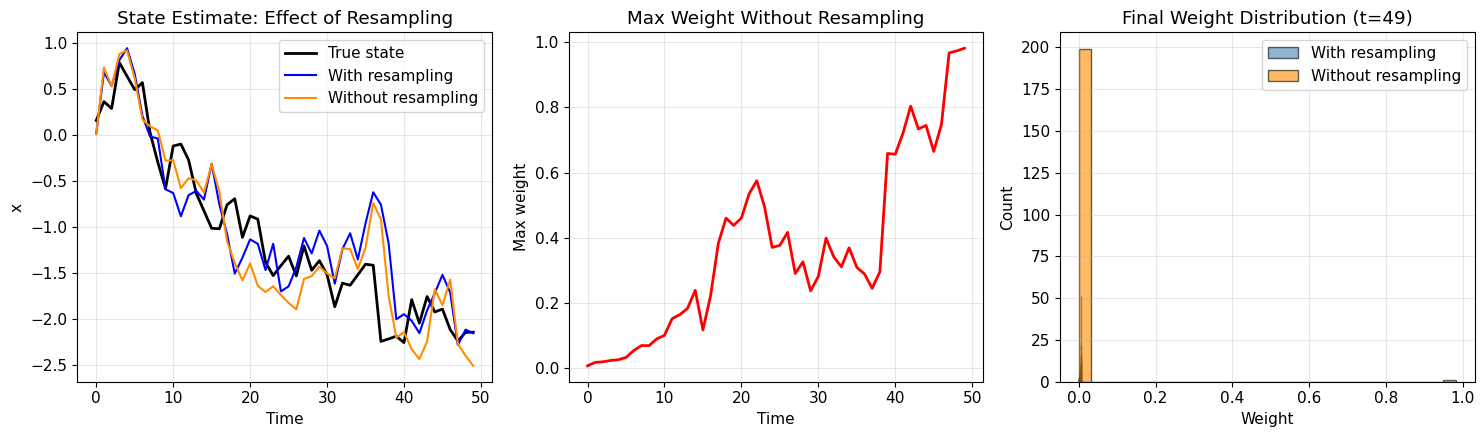

Final ESS with resampling:    187.9 / 200
Final ESS without resampling: 1.0 / 200
Final max weight (no resample): 0.9820


In [11]:
# Run PF without resampling
particles_nr, weights_nr, x_pf_nr = pf_no_resample(y_obs, N, Q, R, x0_mean=0.0, x0_std=1.0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# State estimate comparison
axes[0].plot(range(T), x_true, 'k-', lw=2, label='True state')
axes[0].plot(range(T), x_pf, 'b-', lw=1.5, label='With resampling')
axes[0].plot(range(T), x_pf_nr, color='darkorange', lw=1.5, label='Without resampling')
axes[0].set_title('State Estimate: Effect of Resampling')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('x')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Max weight over time (no resampling)
max_w_nr = np.max(weights_nr, axis=1)
axes[1].plot(range(T), max_w_nr, 'r-', lw=2)
axes[1].set_title('Max Weight Without Resampling')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Max weight')
axes[1].grid(True, alpha=0.3)

# Final weight distribution comparison
axes[2].hist(weights[-1, :], bins=30, alpha=0.6, color='steelblue', edgecolor='black', label='With resampling')
axes[2].hist(weights_nr[-1, :], bins=30, alpha=0.6, color='darkorange', edgecolor='black', label='Without resampling')
axes[2].set_title('Final Weight Distribution (t={})'.format(T-1))
axes[2].set_xlabel('Weight')
axes[2].set_ylabel('Count')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

ess_final_nr = 1.0 / np.sum(weights_nr[-1, :]**2)
print("Final ESS with resampling:    {:.1f} / {}".format(ess[-1], N))
print("Final ESS without resampling: {:.1f} / {}".format(ess_final_nr, N))
print("Final max weight (no resample): {:.4f}".format(max_w_nr[-1]))


## 5. Summary and Practical Guidance

| Component | Purpose | Key Insight |
|-----------|---------|-------------|
| **Propagation** | Move particles through state dynamics | Uses the prior as proposal (bootstrap filter) |
| **Weighting** | Incorporate new observation | Likelihood $p(y_t | x_t^{(i)})$ measures how well each particle explains the data |
| **Resampling** | Eliminate low-weight particles | Restores ESS; prevents weight collapse |
| **ESS** | Monitor approximation quality | Resample when ESS falls below $N/2$ or $N/3$ |

### Practical Notes
- **Number of particles:** More particles reduce Monte Carlo variance but increase cost. Typical values: $N = 100$ to $10,000$.
- **Resampling schemes:** Systematic resampling (used here via `np.random.choice`) is standard; stratified resampling has lower variance.
- **Proposal improvement:** The bootstrap filter uses the prior $p(x_t | x_{t-1})$ as proposal. Better proposals (e.g., Unscented Particle Filter, Extended Kalman proposal) incorporate the latest observation and reduce variance dramatically.
- **Rao-Blackwellization:** If part of the state space is conditionally linear-Gaussian, use a Kalman filter for that part and particles for the rest (Mixture Kalman Filter).

Particle filters are the method of choice for nonlinear, non-Gaussian, and multi-modal sequential inference problems where Kalman filters fail.
